In [1]:
import pandas as pd
import glob
import os
import warnings

warnings.filterwarnings("ignore")

In [2]:


# Define folder path
folder_path = "wishlists/adds.xlsx"


# Read all files into DataFrames and add filename column
adds = pd.read_excel(folder_path, skiprows=2)

adds.rename({"Selected Measure":"additions"}, axis=1, inplace=True)

In [3]:
folder_path = "wishlists/activations.xlsx"


activations  = pd.read_excel(folder_path, skiprows=2)

activations.rename({"Selected Measure":"activations"}, axis=1, inplace=True)

In [4]:
adds = adds.drop("Blank Measure", axis=1)
activations = activations.drop("Blank Measure", axis=1)

In [5]:
adds.drop_duplicates("product").to_clipboard()

In [6]:
folder_path = "wishlists/Annapurna Interactive Historical Revenues - releases_dates.csv"


dates  = pd.read_csv(folder_path)
dates = dates.dropna(subset='pc_release_date')

In [7]:
dates

,product,pc_release_date
0,Faraway,2025-12-31
1,Mixtape,2025-12-31
2,The Lost Wild,2026-11-01
3,Wheel World,2025-07-23
4,BattleSage,2025-06-30
5,to a T,2025-05-28
6,Skin Deep,2025-04-30
7,Lushfoil Photography Sim,2025-04-15
8,Wanderstop,2025-03-11
9,Morsels,2025-02-28


In [8]:
df = pd.merge(adds, activations, on=['product', 'Date'], how='left')

In [9]:
dates['product'].unique()

array(['Faraway', 'Mixtape', 'The Lost Wild', 'Wheel World', 'BattleSage',
       'to a T', 'Skin Deep', 'Lushfoil Photography Sim', 'Wanderstop',
       'Morsels', 'Flock', 'Lorelei and the Laser Eyes', 'Open Roads',
       'Thirsty Suitors', 'Cocoon', 'Storyteller', 'Solar Ash',
       'Hindsight', 'Hohokum', 'Stray', 'Neon White', 'A Memoir Blue',
       'The Pathless', 'The Artful Escape', 'Twelve Minutes', 'Last Stop',
       'Mundaun', 'Maquette', 'Wattam', 'Due Process', 'I Am Dead',
       'The Unfinished Swan', 'Outer Wilds', 'Journey', 'If Found...',
       'Florence', 'Kentucky Route Zero: TV Edition',
       'Sayonara Wild Hearts', 'Ashen', 'Telling Lies', 'Flower',
       'Donut County', 'Gorogoa', 'What Remains of Edith Finch'],
      dtype=object)

In [10]:
dates['pc_release_date'] = pd.to_datetime(dates['pc_release_date'])
df['release_date'] = pd.to_datetime(df['Date'])


In [11]:
release_date_dict = dates.groupby('product')['pc_release_date'].min().to_dict()

In [12]:
release_date_dict

{'A Memoir Blue': Timestamp('2022-03-24 00:00:00'),
 'Ashen': Timestamp('2019-12-09 00:00:00'),
 'BattleSage': Timestamp('2025-06-30 00:00:00'),
 'Cocoon': Timestamp('2023-09-29 00:00:00'),
 'Donut County': Timestamp('2018-08-28 00:00:00'),
 'Due Process': Timestamp('2020-11-03 00:00:00'),
 'Faraway': Timestamp('2025-12-31 00:00:00'),
 'Flock': Timestamp('2024-07-16 00:00:00'),
 'Florence': Timestamp('2020-02-13 00:00:00'),
 'Flower': Timestamp('2019-02-14 00:00:00'),
 'Gorogoa': Timestamp('2017-12-14 00:00:00'),
 'Hindsight': Timestamp('2022-08-04 00:00:00'),
 'Hohokum': Timestamp('2022-07-28 00:00:00'),
 'I Am Dead': Timestamp('2020-10-08 00:00:00'),
 'If Found...': Timestamp('2020-05-19 00:00:00'),
 'Journey': Timestamp('2020-06-11 00:00:00'),
 'Kentucky Route Zero: TV Edition': Timestamp('2020-01-28 00:00:00'),
 'Last Stop': Timestamp('2021-07-22 00:00:00'),
 'Lorelei and the Laser Eyes': Timestamp('2024-05-16 00:00:00'),
 'Lushfoil Photography Sim': Timestamp('2025-04-15 00:00:00'

In [13]:
df['release_date'] = df['product'].map(release_date_dict)


In [14]:
df["DBR"] = (df["Date"] - df["release_date"]).dt.days


In [15]:
df["Weeks_from_Release"] = (df["DBR"] // 7) + 1  # Week 1 starts at 0-7 days


In [16]:
df['cumulative_additions'] = df.groupby('product')['additions'].cumsum()
df['cumulative_activations'] = df.groupby('product')['activations'].cumsum()


In [17]:
df['cumulative_act_rate'] = df['cumulative_activations'] / df['cumulative_additions']
df['act_rate'] = df['activations'] / df['additions']

In [18]:
df.drop_duplicates(subset='product', keep='last').sort_values(by='cumulative_additions', ascending=False)

,Date,product,additions,activations,release_date,DBR,Weeks_from_Release,cumulative_additions,cumulative_activations,cumulative_act_rate,act_rate
132122,2025-05-15,Stray,24,2.0,2022-07-19,1031.0,148.0,10381369,2722545.0,0.262253,0.083333
132115,2025-05-15,Outer Wilds,20,0.0,2020-06-18,1792.0,257.0,4687006,1452747.0,0.309952,0.000000
132104,2025-05-15,Journey,0,0.0,2020-06-11,1799.0,258.0,1828119,701371.0,0.383657,NaN
132134,2025-05-15,What Remains of Edith Finch,8,0.0,2017-04-25,2942.0,421.0,1802143,717723.0,0.398261,0.000000
132113,2025-05-15,Neon White,1,0.0,2022-06-16,1064.0,153.0,1210235,273018.0,0.225591,0.000000
132130,2025-05-15,Twelve Minutes,0,0.0,2021-08-19,1365.0,196.0,1158521,173245.0,0.149540,NaN
132121,2025-05-15,Storyteller,0,0.0,2023-03-23,784.0,113.0,934326,186727.0,0.199852,NaN
132091,2025-05-15,Cocoon,3,0.0,2023-09-29,594.0,85.0,929342,140764.0,0.151466,0.000000
132086,2025-05-15,Ashen,1,0.0,2019-12-09,1984.0,284.0,733936,112632.0,0.153463,0.000000
132099,2025-05-15,Gorogoa,0,0.0,2017-12-14,2709.0,388.0,702266,270948.0,0.385820,NaN


In [19]:

#df['release_date'] = df.groupby('product')['release_date'].transform('min')
#df_combined["DAR"] = df_combined["DAR"].clip(lower=0)


#df = df.query("0 <= Weeks_from_Release <=12")

#df = df.query("'1/1/2015' <= release_date <='1/1/2026'")

#df = df.groupby(["product",'Date', "Weeks_from_Release"], as_index=False)["units"].max()
df = df.groupby(["product", "Weeks_from_Release"], as_index=False)[["additions", 'cumulative_additions','cumulative_activations','act_rate', 'cumulative_act_rate']].max()

In [20]:
df['product'].unique()

array(['A Memoir Blue', 'Ashen', 'BattleSage', 'Cocoon', 'Donut County',
       'Due Process', 'Faraway', 'Flock', 'Florence', 'Flower', 'Gorogoa',
       'Hindsight', 'Hohokum', 'I Am Dead', 'If Found...', 'Journey',
       'Kentucky Route Zero: TV Edition', 'Last Stop',
       'Lorelei and the Laser Eyes', 'Lushfoil Photography Sim',
       'Maquette', 'Mixtape', 'Morsels', 'Mundaun', 'Neon White',
       'Open Roads', 'Outer Wilds', 'Sayonara Wild Hearts', 'Skin Deep',
       'Solar Ash', 'Storyteller', 'Stray', 'Telling Lies',
       'The Artful Escape', 'The Lost Wild', 'The Pathless',
       'The Unfinished Swan', 'Thirsty Suitors', 'Twelve Minutes',
       'Wanderstop', 'Wattam', 'What Remains of Edith Finch',
       'Wheel World', 'to a T'], dtype=object)

In [21]:
title = 'Wheel World'

In [22]:
df.query("product==@title")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
15663,Wheel World,-394.0,0,0,NaN,NaN,NaN
15664,Wheel World,-393.0,0,0,NaN,NaN,NaN
15665,Wheel World,-392.0,0,0,NaN,NaN,NaN
15666,Wheel World,-391.0,0,0,NaN,NaN,NaN
15667,Wheel World,-390.0,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...
16044,Wheel World,-13.0,84,85164,0.0,0.0,0.0
16045,Wheel World,-12.0,58,85500,0.0,0.0,0.0
16046,Wheel World,-11.0,88,85911,0.0,0.0,0.0
16047,Wheel World,-10.0,48,86167,0.0,0.0,0.0


In [23]:
current_cume = df.query("product==@title")['cumulative_additions'].values[-1]
current_week = df.query("product==@title")['Weeks_from_Release'].values[-1]

In [24]:
current_week

-9.0

In [25]:
title_df = df.query("product==@title")

In [26]:
title_df

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
15663,Wheel World,-394.0,0,0,NaN,NaN,NaN
15664,Wheel World,-393.0,0,0,NaN,NaN,NaN
15665,Wheel World,-392.0,0,0,NaN,NaN,NaN
15666,Wheel World,-391.0,0,0,NaN,NaN,NaN
15667,Wheel World,-390.0,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...
16044,Wheel World,-13.0,84,85164,0.0,0.0,0.0
16045,Wheel World,-12.0,58,85500,0.0,0.0,0.0
16046,Wheel World,-11.0,88,85911,0.0,0.0,0.0
16047,Wheel World,-10.0,48,86167,0.0,0.0,0.0


In [27]:
ranked_df = df.query("Weeks_from_Release ==-76").sort_values(by='cumulative_additions', ascending=False)

In [28]:
range = 0.50

high_end = current_cume * (1 + range)
low_end = current_cume * (1 - range)

In [29]:
low_end

43088.5

In [30]:
df_filtered = ranked_df[~ranked_df['product'].str.contains('Soundtrack', case=False, na=False)]
df_filtered.query("additions>0")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
12961,The Lost Wild,-76.0,189,457742,1.0,0.000000,0.000002
11581,Stray,-76.0,491,89848,2.0,0.000000,0.000023
9353,Open Roads,-76.0,33,66594,1.0,0.000000,0.000015
7093,Lushfoil Photography Sim,-76.0,56,56254,2.0,0.000000,0.000036
14233,Twelve Minutes,-76.0,87,49179,0.0,0.000000,0.000000
7902,Mixtape,-76.0,529,47436,0.0,0.000000,0.000000
11230,Storyteller,-76.0,1411,37105,0.0,0.000000,0.000000
10568,Skin Deep,-76.0,13,29056,4.0,0.000000,0.000138
9542,Outer Wilds,-76.0,367,21253,0.0,0.000000,0.000000
13962,Thirsty Suitors,-76.0,12,20323,0.0,0.000000,0.000000


In [31]:
df_filtered.query("@low_end < cumulative_additions <@high_end")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
11581,Stray,-76.0,491,89848,2.0,0.0,0.000023
9353,Open Roads,-76.0,33,66594,1.0,0.0,0.000015
7093,Lushfoil Photography Sim,-76.0,56,56254,2.0,0.0,0.000036
14233,Twelve Minutes,-76.0,87,49179,0.0,0.0,0.000000
7902,Mixtape,-76.0,529,47436,0.0,0.0,0.000000


In [32]:
df_filtered['pct_rank'] = df_filtered['cumulative_additions'].rank(pct=True)

In [33]:
df_filtered

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate,pct_rank
12961,The Lost Wild,-76.0,189,457742,1.0,0.000000,0.000002,1.000000
11581,Stray,-76.0,491,89848,2.0,0.000000,0.000023,0.973684
9353,Open Roads,-76.0,33,66594,1.0,0.000000,0.000015,0.947368
7093,Lushfoil Photography Sim,-76.0,56,56254,2.0,0.000000,0.000036,0.921053
14233,Twelve Minutes,-76.0,87,49179,0.0,0.000000,0.000000,0.894737
7902,Mixtape,-76.0,529,47436,0.0,0.000000,0.000000,0.868421
11230,Storyteller,-76.0,1411,37105,0.0,0.000000,0.000000,0.842105
10568,Skin Deep,-76.0,13,29056,4.0,0.000000,0.000138,0.815789
9542,Outer Wilds,-76.0,367,21253,0.0,0.000000,0.000000,0.789474
13962,Thirsty Suitors,-76.0,12,20323,0.0,0.000000,0.000000,0.763158


In [34]:
df_filtered.query("product==@title")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate,pct_rank
15981,Wheel World,-76.0,23,14070,0.0,0.0,0.0,0.684211


## Wishlist Activation Rates over time.

In [36]:
df = df[~df['product'].str.contains('Soundtrack', case=False, na=False)]


In [37]:
act_rate_df = df.query("Weeks_from_Release >=1")

In [38]:
#act_rate_df["DAR"] = act_rate_df.groupby("product")["DAR"].transform(lambda x: x.clip(lower=0))


In [39]:
act_rate_df

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
221,A Memoir Blue,1.0,1682,20020,925.0,0.261538,0.046204
222,A Memoir Blue,2.0,327,22105,1059.0,0.113497,0.048436
223,A Memoir Blue,3.0,365,24006,1151.0,0.064103,0.048284
224,A Memoir Blue,4.0,229,25382,1238.0,0.092683,0.048859
225,A Memoir Blue,5.0,175,26429,1320.0,0.136752,0.049945
...,...,...,...,...,...,...,...
15658,What Remains of Edith Finch,417.0,1319,1785223,714236.0,0.730071,0.400082
15659,What Remains of Edith Finch,418.0,964,1791064,717097.0,0.710074,0.400666
15660,What Remains of Edith Finch,419.0,951,1796347,717387.0,0.070381,0.400262
15661,What Remains of Edith Finch,420.0,926,1801707,717699.0,0.075676,0.399179


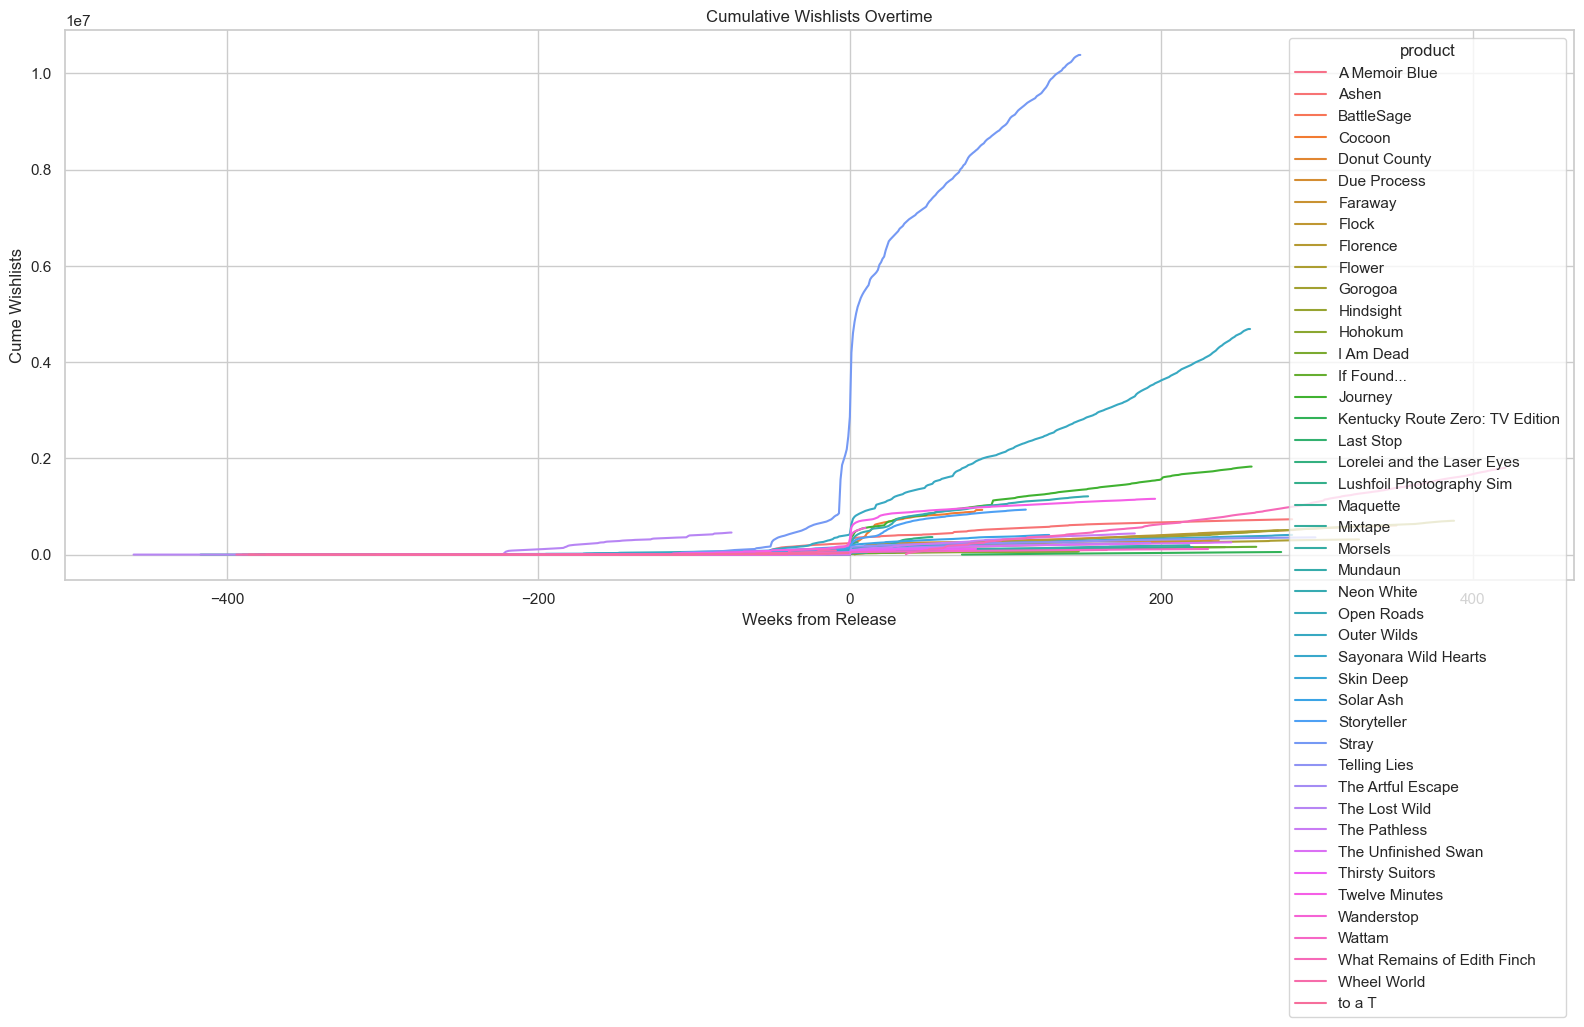

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=df, x="Weeks_from_Release", y="cumulative_additions", hue='product')

# Adding titles and labels
plt.title("Cumulative Wishlists Overtime")
plt.xlabel("Weeks from Release")
plt.ylabel("Cume Wishlists")

# Show the plot
plt.tight_layout()
plt.show()

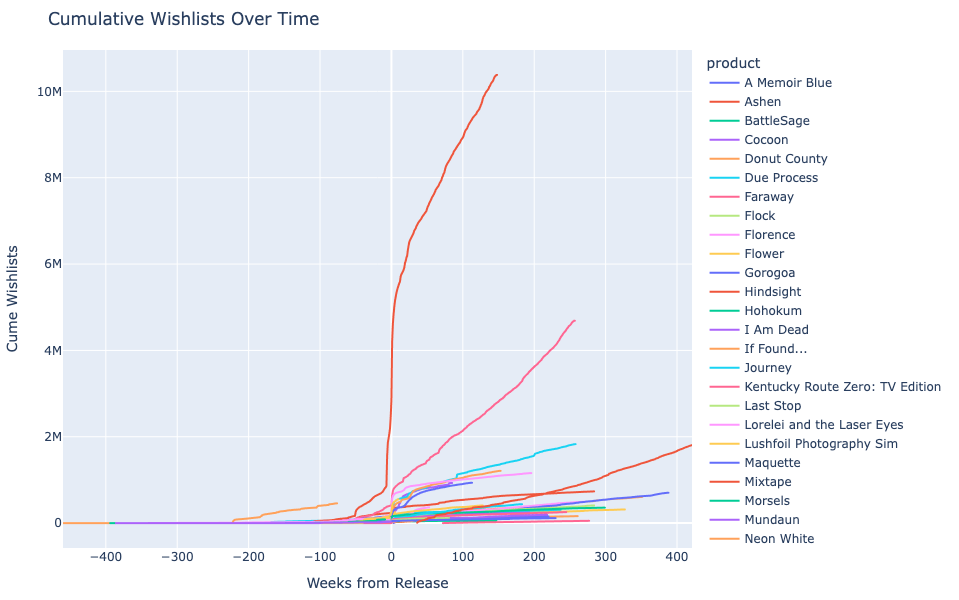

In [41]:
import plotly.express as px

# Create the interactive line plot
fig = px.line(df, 
              x="Weeks_from_Release", 
              y="cumulative_additions", 
              color='product',
              title="Cumulative Wishlists Over Time",
              labels={
                  "Weeks_from_Release": "Weeks from Release",
                  "cumulative_additions": "Cume Wishlists"
              })

# Update the layout for better aesthetics
fig.update_layout(
    autosize=True,
    height=600,
    margin=dict(l=20, r=20, t=50, b=20),
    hovermode='x'
)

# Save as HTML
fig.write_html("docs/cumulative_wishlists_overtime.html")

# Show the interactive plot
fig.show()

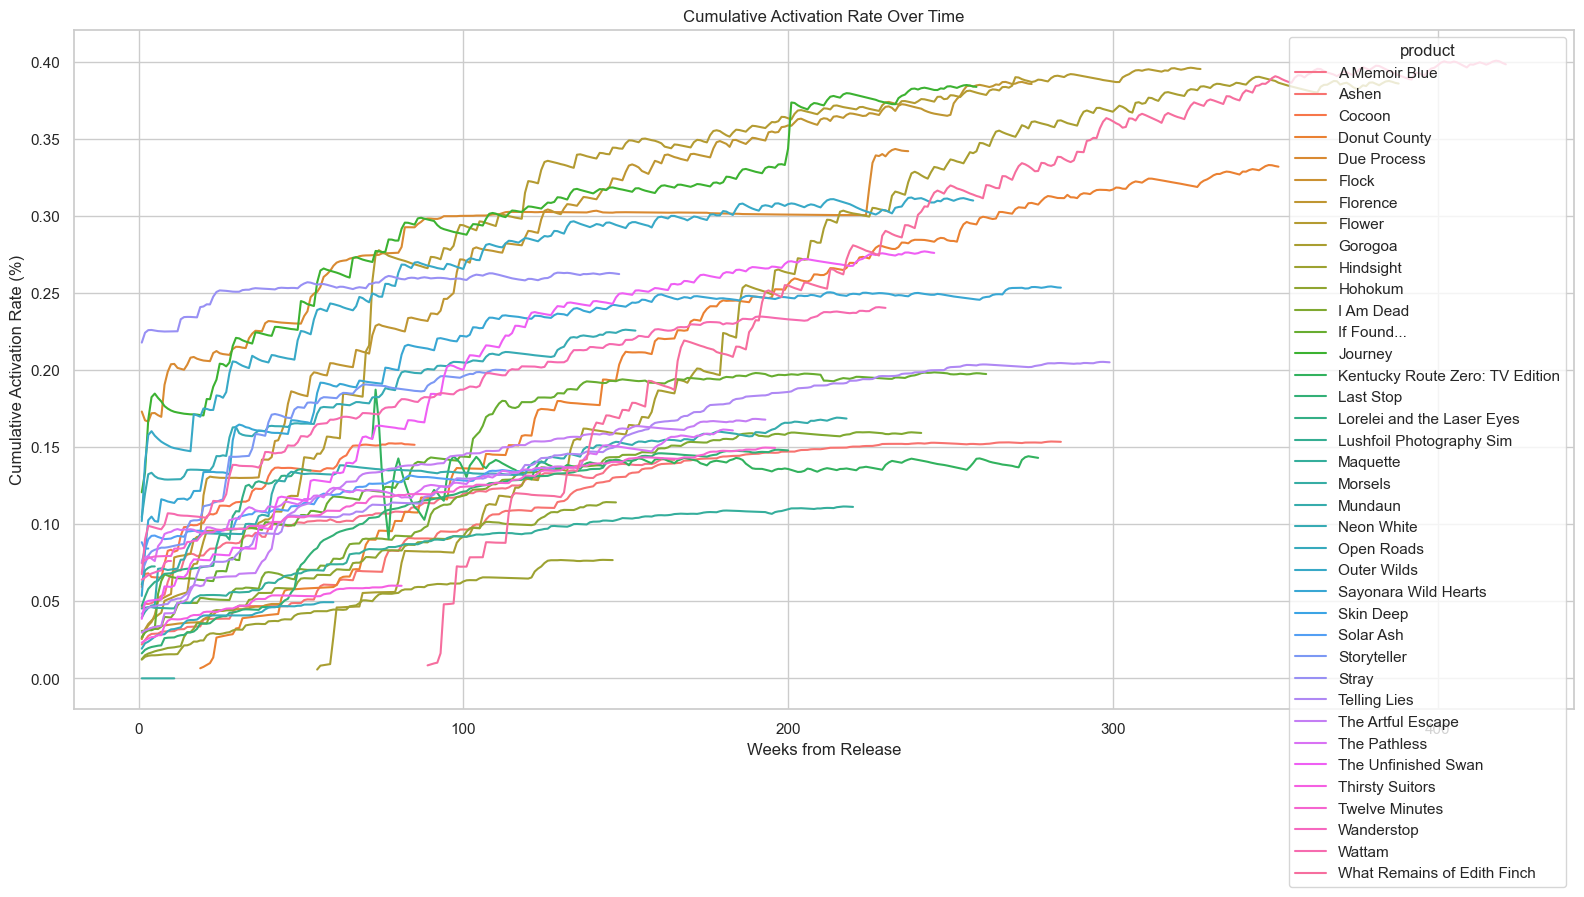

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=act_rate_df, x="Weeks_from_Release", y="cumulative_act_rate", hue='product')


# Adding titles and labels
plt.title("Cumulative Activation Rate Over Time")
plt.xlabel("Weeks from Release")
plt.ylabel("Cumulative Activation Rate (%)")

# Show the plot
plt.tight_layout()
plt.show()

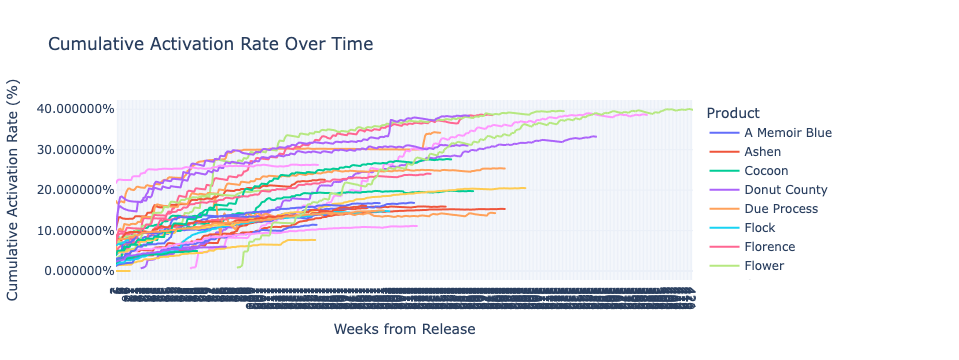

In [43]:
import plotly.express as px

# Create the Plotly line plot
fig = px.line(
    act_rate_df,
    x="Weeks_from_Release",
    y="cumulative_act_rate",
    color='product',
    title="Cumulative Activation Rate Over Time",
    labels={
        "Weeks_from_Release": "Weeks from Release",
        "cumulative_act_rate": "Cumulative Activation Rate (%)"
    },
    template='plotly_white'
)

# Improve layout for readability
fig.update_layout(
    legend_title_text='Product',
    xaxis=dict(tickmode='linear'),
    yaxis_tickformat='%'
)

# Display the plot
fig.show()

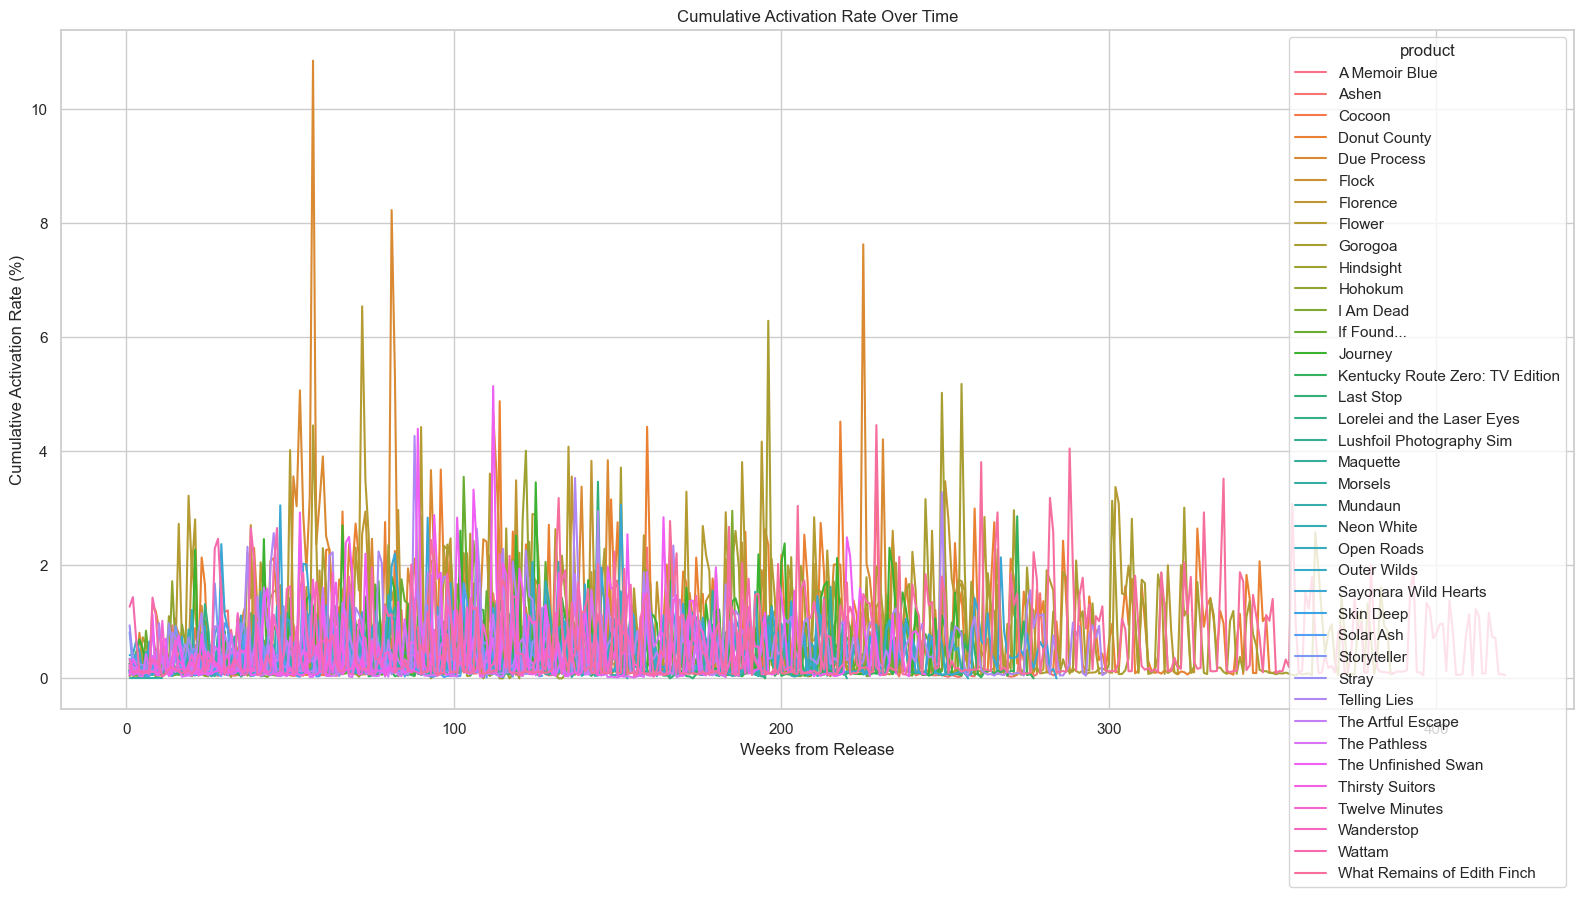

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=act_rate_df, x="Weeks_from_Release", y="act_rate", hue='product')

#plt.ylim(1,25)

# Adding titles and labels
plt.title("Cumulative Activation Rate Over Time")
plt.xlabel("Weeks from Release")
plt.ylabel("Cumulative Activation Rate (%)")

# Show the plot
plt.tight_layout()
plt.show()